# Controlled Perturbation Analysis / 受控扰动实验分析

This notebook analyzes [`controlled_perturbation_analysis_core.csv`](../experiment/controlled_perturbation_analysis_core.csv) for the controlled perturbation study and is organized for manuscript-quality figure generation.

本 notebook 基于 [`controlled_perturbation_analysis_core.csv`](../experiment/controlled_perturbation_analysis_core.csv) 对受控扰动实验进行分析，并按论文图表产出的需求重新组织。

**Objectives / 目标**
- validate the merged baseline + perturbation design / 验证 baseline 与扰动数据的合并设计是否完整
- quantify the sigma-response of `TRE`, `RE`, and `ray gap` / 定量评估 `TRE`、`RE` 与 `ray gap` 随噪声强度的变化
- compare `marker-only` versus `target-only` perturbations / 比较 `marker-only` 与 `target-only`
- test whether angle and distance modulate perturbation sensitivity / 分析角度和距离是否调制噪声敏感性
- export manuscript-ready figures and summary tables / 导出可直接用于论文的图表与汇总表


## Figure Policy and Analysis Unit / 图表规范与分析单元

**Primary analysis unit / 主分析单元**

The primary inferential unit is the **base-condition median**, not the raw perturbation row.  
核心统计单元采用 **base-condition median（每个 base condition 的中位数）**，而不是直接把所有扰动行混在一起做推断。

This choice is deliberate because:
- perturbation rows are repeated random draws within the same geometric condition / 扰动行是在同一几何条件下的重复随机抽样
- baseline counts are not perfectly balanced across the 9 base conditions / baseline 在 9 个 base condition 之间的重复次数并不完全平衡
- several `marker-only + 2 px` conditions show heavy-tailed behavior, so medians are more robust than means / 若干 `marker-only + 2 px` 条件存在明显长尾，中位数比均值更稳健

**TMI / IEEE-oriented figure policy / 面向 TMI 的图表策略**

Figures in this notebook follow the official IEEE journal graphics guidance:
- one-column figures are built around **3.5 in** width / 单栏图宽度按 **3.5 in**
- two-column figures are built around **7.16 in** width / 双栏图宽度按 **7.16 in**
- vector **PDF** and high-resolution **600 dpi PNG** are exported together / 同时导出矢量 **PDF** 与 **600 dpi PNG**
- typography is kept compact and consistent for journal reduction / 字体大小与线宽按期刊缩放后的可读性统一设置
- color is always paired with markers or line styles / 颜色总是和 marker 或线型一起使用，避免只靠颜色传递信息

Official references:
- [IEEE Author Center: Create Graphics for Your Article](https://journals.ieeeauthorcenter.ieee.org/create-your-ieee-journal-article/create-graphics-for-your-article/)
- [IEEE Author Center: Resolution and Size](https://journals.ieeeauthorcenter.ieee.org/create-your-ieee-journal-article/create-graphics-for-your-article/resolution-and-size/)

**Important note on ray gap / 关于 ray gap 的重要说明**

The clean baseline `ray gap` values come from the legacy snapped-zero-gap workflow.  
baseline 的 `ray gap` 来自旧版 snapped-zero-gap 工作流，因此在本 notebook 中：
- `TRE` and `RE` use the clean baseline as a formal reference / `TRE` 与 `RE` 会正式使用 baseline 作为参考
- `ray gap` uses baseline only as a visual zero reference and is formally compared **within perturbation runs only** / `ray gap` 只把 baseline 当作视觉上的零参考，正式统计只在 perturbation runs 内部进行


In [18]:
import warnings
from collections import OrderedDict
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy import stats

warnings.filterwarnings("ignore")

# TMI / IEEE-oriented style
sns.set_theme(style="ticks", context="paper")
mpl.rcParams.update({
    "figure.dpi": 180,
    "savefig.dpi": 600,
    "font.family": "Arial",
    "font.size": 8.6,
    "axes.titlesize": 9.2,
    "axes.labelsize": 8.6,
    "axes.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.labelsize": 8.1,
    "ytick.labelsize": 8.1,
    "legend.fontsize": 8.1,
    "legend.title_fontsize": 8.1,
    "lines.linewidth": 1.4,
    "lines.markersize": 4.6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

SIGMA_ORDER = [0.0, 0.5, 1.0, 2.0]
NOISE_LINE_ORDER = ["marker-only", "target-only"]
ANGLE_ORDER = ["Low", "Medium", "High"]
DISTANCE_ORDER = ["Near", "Mid", "Far"]

NOISE_LABELS = {
    "baseline": "Baseline",
    "marker-only": "Fiducial-coordinate noise",
    "target-only": "Target-coordinate noise",
}
NOISE_COLORS = {
    "baseline": "#333333",
    "marker-only": "#0072B2",
    "target-only": "#D55E00",
}
NOISE_MARKERS = {
    "baseline": "D",
    "marker-only": "o",
    "target-only": "s",
}
NOISE_LINESTYLES = {
    "marker-only": "-",
    "target-only": "--",
}
ANGLE_COLORS = {
    "Low": "#CC3311",
    "Medium": "#E69F00",
    "High": "#009E73",
}
DISTANCE_COLORS = {
    "Near": "#1B9E77",
    "Mid": "#7570B3",
    "Far": "#A6761D",
}

METRIC_INFO = OrderedDict({
    "tre": {
        "label": "TRE (mm)",
        "raw": "tre_mm_raw",
        "cell": "tre_median",
        "delta": "tre_delta",
        "delta_label": "ΔTRE from baseline (mm)",
    },
    "re": {
        "label": "RE (px)",
        "raw": "re_px_raw",
        "cell": "re_median",
        "delta": "re_delta",
        "delta_label": "ΔRE from baseline (px)",
    },
    "gap": {
        "label": "Ray Gap (mm)",
        "raw": "ray_gap_mm_raw",
        "cell": "gap_median",
        "delta": "gap_delta",
        "delta_label": "Ray gap (mm)",
    },
})


In [19]:
# Resolve paths and reusable helpers
cwd = Path.cwd().resolve()
if (cwd / "Biplane.py").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "Biplane.py").exists():
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

CSV_PATH = PROJECT_ROOT / "experiment" / "controlled_perturbation_analysis_core.csv"
FIG_DIR = PROJECT_ROOT / "Analysis" / "figures" / "experiment_results_analysis"
TABLE_DIR = PROJECT_ROOT / "Analysis" / "tables" / "experiment_results_analysis"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

ONE_COL = 3.50
TWO_COL = 7.16


def save_fig(fig, stem: str):
    png_path = FIG_DIR / f"{stem}.png"
    pdf_path = FIG_DIR / f"{stem}.pdf"
    fig.savefig(png_path, dpi=600, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved: {png_path.relative_to(PROJECT_ROOT)}")
    print(f"Saved: {pdf_path.relative_to(PROJECT_ROOT)}")


def panel_tag(ax, tag: str):
    ax.text(-0.09, 1.10, f"({tag})", transform=ax.transAxes, fontsize=8.6, fontweight="bold", va="top")


def polish_axis(ax, grid_axis="y"):
    ax.grid(axis=grid_axis, color="#E6E6E6", linewidth=0.45)
    ax.spines["left"].set_linewidth(0.7)
    ax.spines["bottom"].set_linewidth(0.7)
    ax.tick_params(axis="both", width=0.65, length=2.5, pad=1.5)


def format_p(p: float) -> str:
    if pd.isna(p):
        return "NA"
    if p < 1e-3:
        return "<0.001"
    return f"{p:.3f}"


def median_iqr_table(data: pd.DataFrame, group_cols, value_col: str) -> pd.DataFrame:
    return (
        data.groupby(group_cols, observed=True)[value_col]
        .agg(
            center="median",
            q1=lambda s: s.quantile(0.25),
            q3=lambda s: s.quantile(0.75),
        )
        .reset_index()
    )


def summarize_range(data: pd.Series) -> str:
    return f"{data.min():.3f}-{data.max():.3f}"


In [20]:
# Load, validate, and engineer features
raw = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
df = raw.copy()

required_cols = [
    "analysis_row_kind",
    "ray_gap_regime",
    "dataset",
    "projection_mode",
    "point_id",
    "distance_group",
    "angle_group",
    "base_condition_id",
    "noise_type",
    "noise_sigma_px",
    "repeat_index",
    "success_flag",
    "is_clean_baseline",
    "tre_mm_raw",
    "re_px_raw",
    "ray_gap_mm_raw",
    "marker_sort_rms",
    "calibration_reproj_rms",
]
missing_required = [c for c in required_cols if c not in df.columns]
assert not missing_required, f"Missing required columns: {missing_required}"

if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

numeric_cols = [
    "shot2_angle_deg",
    "shot3_angle_m3_m1_deg",
    "shot3_angle_m3_m2_deg",
    "testpoint_x",
    "testpoint_y",
    "testpoint_z",
    "testpoint_marker_distance_mean_mm",
    "noise_sigma_px",
    "repeat_index",
    "success_flag",
    "is_clean_baseline",
    "tre_mm_raw",
    "re_px_raw",
    "ray_gap_mm_raw",
    "marker_sort_rms",
    "calibration_reproj_rms",
    "markers_sorted",
    "perspective_calibration_ready",
    "usable_for_ray_gap_distribution",
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df[df["success_flag"].eq(1)].copy()
df["projection_mode"] = df["projection_mode"].astype(str).str.strip().str.lower()
df["noise_type"] = pd.Categorical(df["noise_type"], categories=["baseline", "marker-only", "target-only"], ordered=True)
df["angle_group"] = pd.Categorical(df["angle_group"], categories=ANGLE_ORDER, ordered=True)
df["distance_group"] = pd.Categorical(df["distance_group"], categories=DISTANCE_ORDER, ordered=True)

key_cols = [
    "point_id", "distance_group", "angle_group", "base_condition_id",
    "noise_type", "noise_sigma_px", "repeat_index",
    "tre_mm_raw", "re_px_raw", "ray_gap_mm_raw",
]
duplicate_condition_rows = int(df.duplicated(subset=["base_condition_id", "noise_type", "noise_sigma_px", "repeat_index"]).sum())
duplicate_record_ids = int(df["experiment_record_id"].duplicated().sum()) if "experiment_record_id" in df.columns else 0
key_missing_total = int(df[key_cols].isna().sum().sum())

cell = (
    df.groupby(
        ["analysis_row_kind", "ray_gap_regime", "usable_for_ray_gap_distribution",
         "point_id", "distance_group", "angle_group", "base_condition_id", "noise_type", "noise_sigma_px"],
        as_index=False,
        observed=True,
    )
    .agg(
        n=("tre_mm_raw", "size"),
        tre_mean=("tre_mm_raw", "mean"),
        tre_median=("tre_mm_raw", "median"),
        tre_sd=("tre_mm_raw", "std"),
        tre_q1=("tre_mm_raw", lambda s: s.quantile(0.25)),
        tre_q3=("tre_mm_raw", lambda s: s.quantile(0.75)),
        re_mean=("re_px_raw", "mean"),
        re_median=("re_px_raw", "median"),
        re_sd=("re_px_raw", "std"),
        re_q1=("re_px_raw", lambda s: s.quantile(0.25)),
        re_q3=("re_px_raw", lambda s: s.quantile(0.75)),
        gap_mean=("ray_gap_mm_raw", "mean"),
        gap_median=("ray_gap_mm_raw", "median"),
        gap_sd=("ray_gap_mm_raw", "std"),
        gap_q1=("ray_gap_mm_raw", lambda s: s.quantile(0.25)),
        gap_q3=("ray_gap_mm_raw", lambda s: s.quantile(0.75)),
        marker_sort_rms_median=("marker_sort_rms", "median"),
        calibration_reproj_rms_median=("calibration_reproj_rms", "median"),
    )
)

baseline_cell = cell[cell["noise_type"].eq("baseline")].copy()
pert_cell = cell[cell["noise_type"].isin(NOISE_LINE_ORDER)].copy()

baseline_ref = baseline_cell[
    ["base_condition_id", "point_id", "distance_group", "angle_group", "tre_median", "re_median", "gap_median"]
].rename(columns={
    "tre_median": "tre_baseline",
    "re_median": "re_baseline",
    "gap_median": "gap_baseline",
})

delta_cell = pert_cell.merge(
    baseline_ref,
    on=["base_condition_id", "point_id", "distance_group", "angle_group"],
    how="left",
)
delta_cell["tre_delta"] = delta_cell["tre_median"] - delta_cell["tre_baseline"]
delta_cell["re_delta"] = delta_cell["re_median"] - delta_cell["re_baseline"]
# Ray gap baseline is a legacy zero-reference, so delta is numerically identical but interpreted as an anchored reference only.
delta_cell["gap_delta"] = delta_cell["gap_median"]

baseline_for_plot = pd.concat(
    [baseline_cell.assign(noise_type=noise) for noise in NOISE_LINE_ORDER],
    ignore_index=True,
)
tre_re_plot = pd.concat([baseline_for_plot, pert_cell], ignore_index=True, sort=False)

delta_zero = pd.concat(
    [
        baseline_cell.assign(noise_type=noise, tre_delta=0.0, re_delta=0.0, gap_delta=0.0)
        for noise in NOISE_LINE_ORDER
    ],
    ignore_index=True,
    sort=False,
)
delta_plot = pd.concat([delta_zero, delta_cell], ignore_index=True, sort=False)

overall_tre_plot = median_iqr_table(tre_re_plot, ["noise_type", "noise_sigma_px"], "tre_median")
overall_re_plot = median_iqr_table(tre_re_plot, ["noise_type", "noise_sigma_px"], "re_median")
overall_gap_plot = median_iqr_table(delta_cell, ["noise_type", "noise_sigma_px"], "gap_median")

angle_tre_plot = median_iqr_table(delta_plot, ["angle_group", "noise_type", "noise_sigma_px"], "tre_delta")
distance_tre_plot = median_iqr_table(delta_plot, ["distance_group", "noise_type", "noise_sigma_px"], "tre_delta")

sigma_tests = []
for metric, baseline_col in [("tre_median", "tre_baseline"), ("re_median", "re_baseline")]:
    metric_name = "TRE" if metric == "tre_median" else "RE"
    for noise in NOISE_LINE_ORDER:
        sub = delta_cell[delta_cell["noise_type"].eq(noise)].copy()
        piv = (
            sub.pivot(index="base_condition_id", columns="noise_sigma_px", values=metric)
            .reindex(columns=[0.5, 1.0, 2.0])
        )
        base = (
            sub[["base_condition_id", baseline_col]]
            .drop_duplicates()
            .set_index("base_condition_id")[baseline_col]
        )
        mat = pd.concat([base.rename(0.0), piv], axis=1).dropna()
        stat, p = stats.friedmanchisquare(mat[0.0], mat[0.5], mat[1.0], mat[2.0])
        rho, rho_p = stats.spearmanr(np.tile(SIGMA_ORDER, len(mat)), mat.to_numpy().reshape(-1))
        sigma_tests.append({
            "metric": metric_name,
            "noise_type": noise,
            "n_base_conditions": len(mat),
            "friedman_stat": stat,
            "friedman_p": p,
            "spearman_rho": rho,
            "spearman_p": rho_p,
            "baseline_median": mat[0.0].median(),
            "sigma2_median": mat[2.0].median(),
            "sigma2_minus_baseline": mat[2.0].median() - mat[0.0].median(),
        })

for noise in NOISE_LINE_ORDER:
    sub = (
        delta_cell[delta_cell["noise_type"].eq(noise)]
        .pivot(index="base_condition_id", columns="noise_sigma_px", values="gap_median")
        .reindex(columns=[0.5, 1.0, 2.0])
        .dropna()
    )
    stat, p = stats.friedmanchisquare(sub[0.5], sub[1.0], sub[2.0])
    rho, rho_p = stats.spearmanr(np.tile([0.5, 1.0, 2.0], len(sub)), sub.to_numpy().reshape(-1))
    sigma_tests.append({
        "metric": "Ray gap",
        "noise_type": noise,
        "n_base_conditions": len(sub),
        "friedman_stat": stat,
        "friedman_p": p,
        "spearman_rho": rho,
        "spearman_p": rho_p,
        "baseline_median": np.nan,
        "sigma2_median": sub[2.0].median(),
        "sigma2_minus_baseline": np.nan,
    })

sigma_tests = pd.DataFrame(sigma_tests)

paired_tests = []
for metric, source_col in [("TRE", "tre_delta"), ("RE", "re_delta"), ("Ray gap", "gap_median")]:
    for sigma in [0.5, 1.0, 2.0]:
        sub = delta_cell[delta_cell["noise_sigma_px"].eq(sigma)].copy()
        piv = sub.pivot(index="base_condition_id", columns="noise_type", values=source_col).dropna()
        stat, p = stats.wilcoxon(piv["marker-only"], piv["target-only"])
        paired_tests.append({
            "metric": metric,
            "noise_sigma_px": sigma,
            "n_base_conditions": len(piv),
            "wilcoxon_stat": stat,
            "wilcoxon_p": p,
            "marker_median": piv["marker-only"].median(),
            "target_median": piv["target-only"].median(),
            "median_difference_marker_minus_target": (piv["marker-only"] - piv["target-only"]).median(),
        })
paired_tests = pd.DataFrame(paired_tests)

sigma2_delta = delta_cell[delta_cell["noise_sigma_px"].eq(2.0)].copy()
sigma2_angle_summary = (
    sigma2_delta.groupby(["angle_group", "noise_type"], as_index=False, observed=True)[["tre_delta", "re_delta", "gap_delta"]]
    .median()
)
sigma2_distance_summary = (
    sigma2_delta.groupby(["distance_group", "noise_type"], as_index=False, observed=True)[["tre_delta", "re_delta", "gap_delta"]]
    .median()
)

heatmap_tre = (
    sigma2_delta.pivot_table(index="distance_group", columns=["noise_type", "angle_group"], values="tre_delta", aggfunc="median")
    .reindex(index=DISTANCE_ORDER)
)

heatmap_tre_marker = heatmap_tre["marker-only"].reindex(columns=ANGLE_ORDER)
heatmap_tre_target = heatmap_tre["target-only"].reindex(columns=ANGLE_ORDER)

row_tail = (
    df[df["analysis_row_kind"].eq("perturbation_run")]
    .groupby(["distance_group", "angle_group", "noise_type", "noise_sigma_px"], as_index=False, observed=True)
    .agg(
        tre_mean=("tre_mm_raw", "mean"),
        tre_median=("tre_mm_raw", "median"),
        re_mean=("re_px_raw", "mean"),
        re_median=("re_px_raw", "median"),
    )
)
row_tail["tre_mean_median_ratio"] = row_tail["tre_mean"] / row_tail["tre_median"]
row_tail["re_mean_median_ratio"] = row_tail["re_mean"] / row_tail["re_median"]
heavy_tail_table = row_tail.sort_values("tre_mean_median_ratio", ascending=False).reset_index(drop=True)

max_rows = (
    df[df["analysis_row_kind"].eq("perturbation_run")]
    .sort_values("tre_mm_raw", ascending=False)
    [["experiment_record_id", "point_id", "distance_group", "angle_group", "noise_type", "noise_sigma_px", "repeat_index", "tre_mm_raw", "re_px_raw", "ray_gap_mm_raw"]]
    .head(10)
)

qc_summary = pd.DataFrame([
    {"Item": "Total rows", "Value": len(df)},
    {"Item": "Baseline rows", "Value": int(df["noise_type"].eq("baseline").sum())},
    {"Item": "Perturbation rows", "Value": int(df["analysis_row_kind"].eq("perturbation_run").sum())},
    {"Item": "Unique test points", "Value": int(df["point_id"].nunique())},
    {"Item": "Unique base conditions", "Value": int(df["base_condition_id"].nunique())},
    {"Item": "Duplicate condition rows", "Value": duplicate_condition_rows},
    {"Item": "Duplicate experiment_record_id", "Value": duplicate_record_ids},
    {"Item": "Missing key values", "Value": key_missing_total},
])

matrix_table = (
    df.groupby(["distance_group", "angle_group", "noise_type", "noise_sigma_px"], as_index=False, observed=True)
    .size()
    .rename(columns={"size": "n_rows"})
    .sort_values(["distance_group", "angle_group", "noise_type", "noise_sigma_px"])
)

baseline_count_table = baseline_cell[
    ["distance_group", "angle_group", "base_condition_id", "n"]
].sort_values(["distance_group", "angle_group"])

display(Markdown("### Loaded dataset"))
display(qc_summary)


### Loaded dataset

,Item,Value
0,Total rows,2754
1,Baseline rows,54
2,Perturbation rows,2700
3,Unique test points,3
4,Unique base conditions,9
5,Duplicate condition rows,0
6,Duplicate experiment_record_id,0
7,Missing key values,0


## Baseline Reconstruction Figures / ???????\n
\n
This section regenerates the manuscript baseline figures from `experiment_results.csv`, using terminology aligned with the paper: localization fiducial-plane normal-angle group and target-to-fiducial distance.\n

Saved: Analysis\figures\experiment_results_analysis\fig01_angle_effect.png
Saved: Analysis\figures\experiment_results_analysis\fig01_angle_effect.pdf


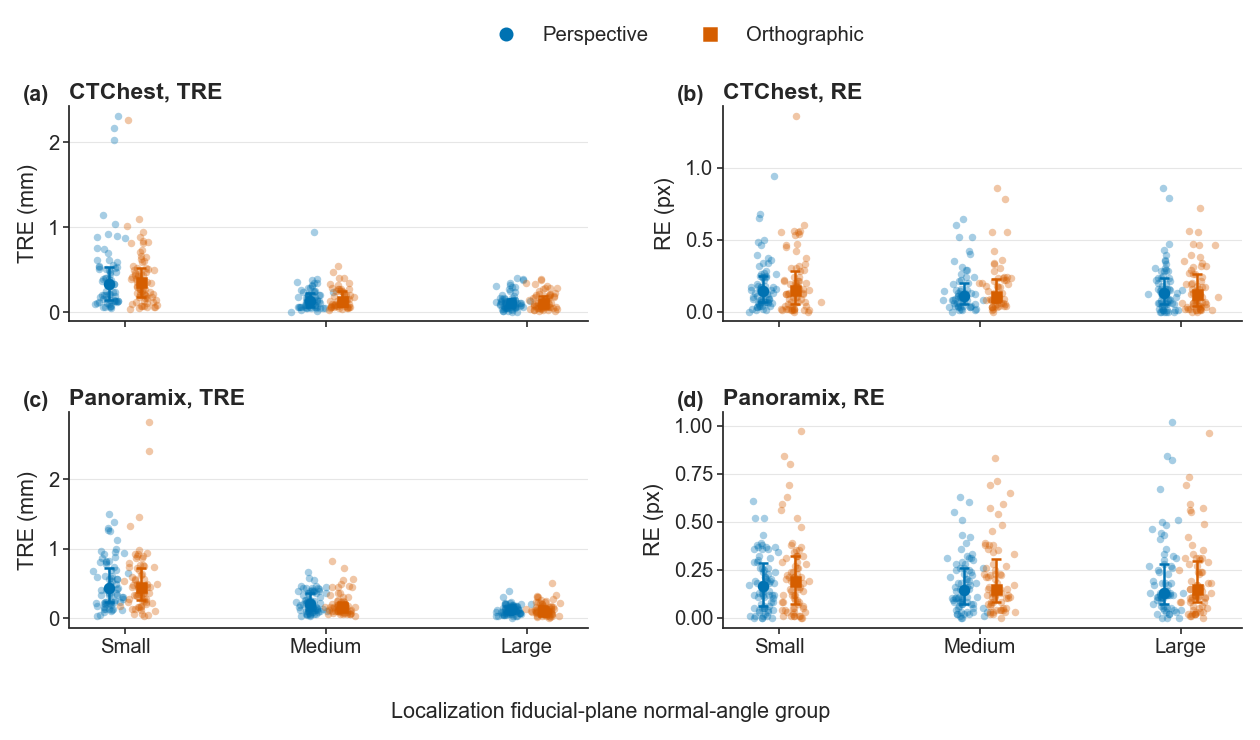

Saved: Analysis\figures\experiment_results_analysis\fig03_distance_effect.png
Saved: Analysis\figures\experiment_results_analysis\fig03_distance_effect.pdf


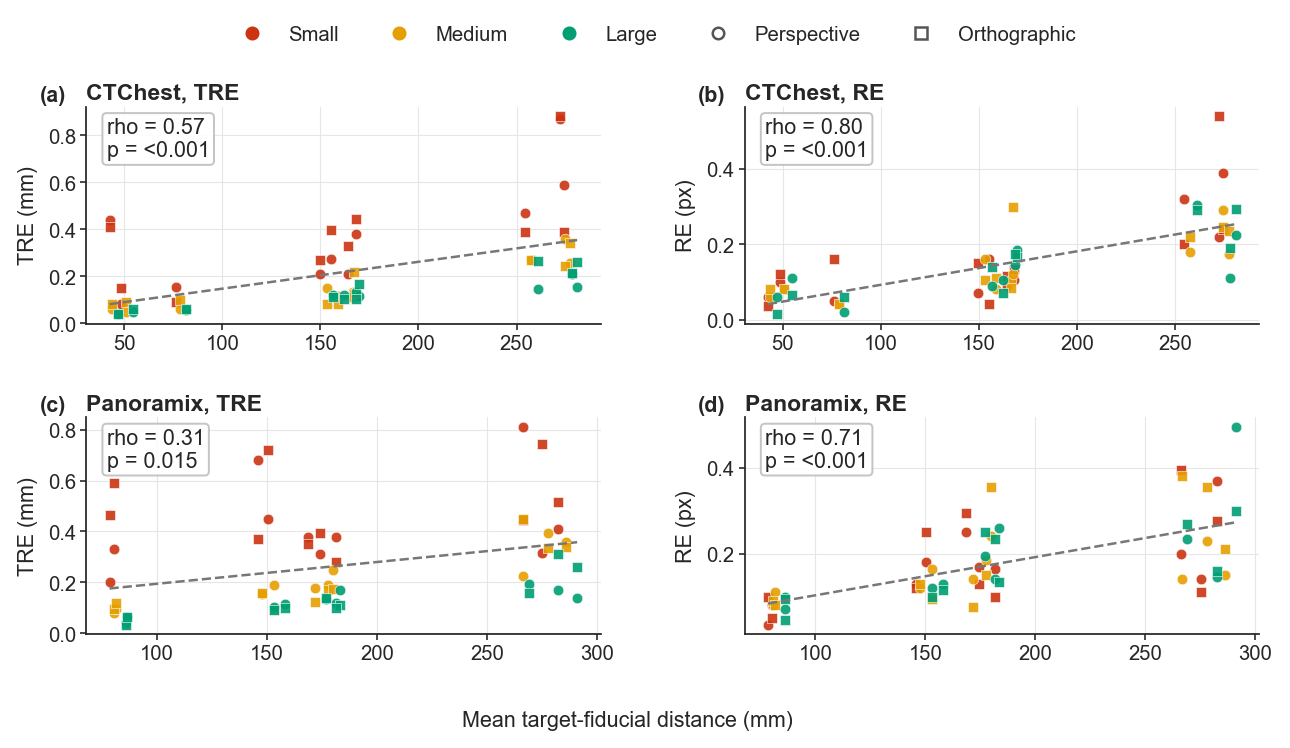

Saved: Analysis\figures\experiment_results_analysis\fig05_repeatability.png
Saved: Analysis\figures\experiment_results_analysis\fig05_repeatability.pdf


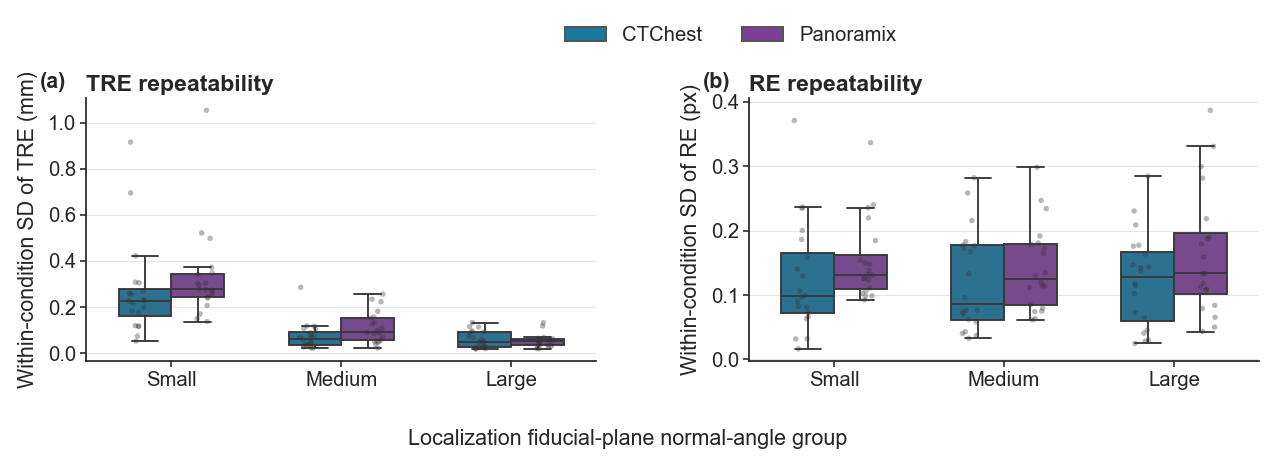

In [21]:
# Baseline reconstruction figures used in the manuscript
BASELINE_CSV_PATH = PROJECT_ROOT / "experiment" / "experiment_results.csv"
baseline_raw = pd.read_csv(BASELINE_CSV_PATH, encoding="utf-8-sig")
baseline = baseline_raw.copy()

for col in [
    "shot2_angle_deg", "testpoint_marker_distance_mean_mm", "tre_value_mm",
    "reprojection_error_px", "repeat_index", "success_flag",
]:
    baseline[col] = pd.to_numeric(baseline[col], errors="coerce")

baseline = baseline[baseline["success_flag"].eq(1)].copy()
baseline = baseline[baseline["projection_mode"].isin(["perspective", "orthographic"])].copy()
baseline["projection_mode"] = baseline["projection_mode"].str.lower()
baseline["dataset_label"] = baseline["dataset"].replace({"Panoramix-cropped": "Panoramix"})

ANGLE_LABELS = ["Small", "Medium", "Large"]
MODE_LABELS = {"perspective": "Perspective", "orthographic": "Orthographic"}
MODE_COLORS = {"perspective": "#0072B2", "orthographic": "#D55E00"}
MODE_MARKERS = {"perspective": "o", "orthographic": "s"}
ANGLE_DISPLAY_COLORS = {"Small": "#CC3311", "Medium": "#E69F00", "Large": "#009E73"}
DATASET_ORDER = ["CTChest", "Panoramix"]

angle_maps = {}
for dataset, sub in baseline.groupby("dataset_label"):
    values = sorted(sub["shot2_angle_deg"].dropna().round(2).unique())
    angle_maps[dataset] = {value: label for value, label in zip(values, ANGLE_LABELS)}

def assign_angle_group(row):
    rounded = round(float(row["shot2_angle_deg"]), 2)
    return angle_maps.get(row["dataset_label"], {}).get(rounded, np.nan)

baseline["localization_angle_group"] = baseline.apply(assign_angle_group, axis=1)
baseline["localization_angle_group"] = pd.Categorical(
    baseline["localization_angle_group"], categories=ANGLE_LABELS, ordered=True
)
baseline["projection_mode"] = pd.Categorical(
    baseline["projection_mode"], categories=["perspective", "orthographic"], ordered=True
)

condition = (
    baseline.groupby(["dataset_label", "projection_mode", "point_id", "localization_angle_group"], observed=True)
    .agg(
        tre_median=("tre_value_mm", "median"),
        re_median=("reprojection_error_px", "median"),
        tre_sd=("tre_value_mm", "std"),
        re_sd=("reprojection_error_px", "std"),
        target_fiducial_distance_mm=("testpoint_marker_distance_mean_mm", "mean"),
        n=("tre_value_mm", "size"),
    )
    .reset_index()
)

# Fig. 3: localization fiducial-plane normal-angle effect
fig, axes = plt.subplots(2, 2, figsize=(TWO_COL, 4.2), sharex=True)
fig.subplots_adjust(left=0.08, right=0.99, bottom=0.17, top=0.86, hspace=0.42, wspace=0.26)
panel_specs = [
    ("CTChest", "tre_value_mm", "TRE (mm)", "CTChest, TRE"),
    ("CTChest", "reprojection_error_px", "RE (px)", "CTChest, RE"),
    ("Panoramix", "tre_value_mm", "TRE (mm)", "Panoramix, TRE"),
    ("Panoramix", "reprojection_error_px", "RE (px)", "Panoramix, RE"),
]
for ax, (dataset, value_col, ylabel, title), tag in zip(axes.flat, panel_specs, list("abcd")):
    sub = baseline[baseline["dataset_label"].eq(dataset)].copy()
    for mode in ["perspective", "orthographic"]:
        mode_sub = sub[sub["projection_mode"].eq(mode)]
        xs = mode_sub["localization_angle_group"].cat.codes.astype(float).to_numpy()
        rng = np.random.default_rng(1200 + ord(tag) + (0 if mode == "perspective" else 10))
        jitter = rng.normal(0, 0.035, len(mode_sub)) + (-0.08 if mode == "perspective" else 0.08)
        ax.scatter(xs + jitter, mode_sub[value_col], s=9, color=MODE_COLORS[mode], alpha=0.35, linewidth=0)
        summary = (
            mode_sub.groupby("localization_angle_group", observed=True)[value_col]
            .agg(center="median", q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75))
            .reindex(ANGLE_LABELS)
        )
        xpos = np.arange(len(ANGLE_LABELS)) + (-0.08 if mode == "perspective" else 0.08)
        yerr = np.vstack([summary["center"] - summary["q1"], summary["q3"] - summary["center"]])
        ax.errorbar(xpos, summary["center"], yerr=yerr, fmt=MODE_MARKERS[mode], color=MODE_COLORS[mode],
                    capsize=2.0, linewidth=1.0, markersize=3.6)
    panel_tag(ax, tag)
    ax.set_title(title, loc="left", fontweight="bold", pad=3)
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(len(ANGLE_LABELS)), ANGLE_LABELS)
    ax.set_xlabel("")
    polish_axis(ax)

fig.supxlabel("Localization fiducial-plane normal-angle group", y=0.045, fontsize=8.6)
fig.legend(
    handles=[Line2D([0], [0], color=MODE_COLORS[m], marker=MODE_MARKERS[m], linestyle="None", label=MODE_LABELS[m]) for m in ["perspective", "orthographic"]],
    loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.55, 0.99),
)
save_fig(fig, "fig01_angle_effect")
plt.show()

# Fig. 4: target-to-fiducial distance effect
fig, axes = plt.subplots(2, 2, figsize=(TWO_COL, 4.25), sharex=False)
fig.subplots_adjust(left=0.08, right=0.99, bottom=0.17, top=0.86, hspace=0.43, wspace=0.28)
panel_specs = [
    ("CTChest", "tre_median", "TRE (mm)", "CTChest, TRE"),
    ("CTChest", "re_median", "RE (px)", "CTChest, RE"),
    ("Panoramix", "tre_median", "TRE (mm)", "Panoramix, TRE"),
    ("Panoramix", "re_median", "RE (px)", "Panoramix, RE"),
]
for ax, (dataset, value_col, ylabel, title), tag in zip(axes.flat, panel_specs, list("abcd")):
    sub = condition[condition["dataset_label"].eq(dataset)].dropna(subset=["target_fiducial_distance_mm", value_col])
    for angle in ANGLE_LABELS:
        for mode in ["perspective", "orthographic"]:
            pts = sub[sub["localization_angle_group"].eq(angle) & sub["projection_mode"].eq(mode)]
            ax.scatter(
                pts["target_fiducial_distance_mm"], pts[value_col],
                s=18, marker=MODE_MARKERS[mode], color=ANGLE_DISPLAY_COLORS[angle],
                edgecolor="white", linewidth=0.25, alpha=0.90,
            )
    if len(sub) >= 3:
        x = sub["target_fiducial_distance_mm"].to_numpy()
        y = sub[value_col].to_numpy()
        slope, intercept = np.polyfit(x, y, 1)
        xx = np.linspace(np.nanmin(x), np.nanmax(x), 100)
        ax.plot(xx, slope * xx + intercept, color="#777777", linestyle="--", linewidth=1.0)
        rho, pval = stats.spearmanr(x, y)
        ax.text(0.04, 0.95, f"rho = {rho:.2f}\np = {format_p(pval)}", transform=ax.transAxes,
                ha="left", va="top", bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#BFBFBF", alpha=0.9))
    panel_tag(ax, tag)
    ax.set_title(title, loc="left", fontweight="bold", pad=3)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    polish_axis(ax, grid_axis="both")

fig.supxlabel("Mean target-fiducial distance (mm)", y=0.045, fontsize=8.6)
fig.legend(
    handles=[
        *[Line2D([0], [0], color=ANGLE_DISPLAY_COLORS[g], marker="o", linestyle="None", label=g) for g in ANGLE_LABELS],
        Line2D([0], [0], color="#555555", marker="o", linestyle="None", markerfacecolor="none", label="Perspective"),
        Line2D([0], [0], color="#555555", marker="s", linestyle="None", markerfacecolor="none", label="Orthographic"),
    ],
    loc="upper center", ncol=5, frameon=False, bbox_to_anchor=(0.52, 0.99),
)
save_fig(fig, "fig03_distance_effect")
plt.show()

# Fig. 5: repeatability
fig, axes = plt.subplots(1, 2, figsize=(TWO_COL, 2.65), sharex=True)
fig.subplots_adjust(left=0.08, right=0.99, bottom=0.25, top=0.80, wspace=0.30)
repeatability_long = condition.melt(
    id_vars=["dataset_label", "projection_mode", "point_id", "localization_angle_group"],
    value_vars=["tre_sd", "re_sd"],
    var_name="metric",
    value_name="within_condition_sd",
).dropna()
metric_specs = [("tre_sd", "Within-condition SD of TRE (mm)", "TRE repeatability"), ("re_sd", "Within-condition SD of RE (px)", "RE repeatability")]
for ax, (metric, ylabel, title), tag in zip(axes, metric_specs, ["a", "b"]):
    sub = repeatability_long[repeatability_long["metric"].eq(metric)]
    sns.boxplot(
        data=sub, x="localization_angle_group", y="within_condition_sd", hue="dataset_label",
        order=ANGLE_LABELS, hue_order=DATASET_ORDER, ax=ax, width=0.62,
        palette={"CTChest": "#1B78A0", "Panoramix": "#7B3F98"}, fliersize=0, linewidth=0.75,
    )
    sns.stripplot(
        data=sub, x="localization_angle_group", y="within_condition_sd", hue="dataset_label",
        order=ANGLE_LABELS, hue_order=DATASET_ORDER, ax=ax, dodge=True,
        palette={"CTChest": "#333333", "Panoramix": "#333333"}, size=2.2, alpha=0.35, linewidth=0,
    )
    panel_tag(ax, tag)
    ax.set_title(title, loc="left", fontweight="bold", pad=3)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    polish_axis(ax)
    if ax.get_legend() is not None:
        ax.get_legend().remove()

fig.supxlabel("Localization fiducial-plane normal-angle group", y=0.065, fontsize=8.6)
fig.legend(
    handles=[Patch(facecolor="#1B78A0", edgecolor="#555555", label="CTChest"), Patch(facecolor="#7B3F98", edgecolor="#555555", label="Panoramix")],
    loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.58, 0.99),
)
save_fig(fig, "fig05_repeatability")
plt.show()


## 1. Dataset Integrity and Design Completeness / 数据完整性与实验设计完备性

Before formal inference, the notebook checks whether the merged baseline + perturbation table preserves the intended `3 distance groups x 3 angle groups x 2 noise types x 3 sigma levels x 50 repeats` structure.

在正式统计前，先验证合并后的 baseline + perturbation 数据是否保留了预期的 `3 distance groups x 3 angle groups x 2 noise types x 3 sigma levels x 50 repeats` 结构。


In [22]:
display(Markdown(
    f'''
### QC summary
- Valid rows: **{len(df)}**
- Base conditions: **{df['base_condition_id'].nunique()}**
- Test points: **{df['point_id'].nunique()}**
- Duplicate condition rows: **{duplicate_condition_rows}**
- Missing key values: **{key_missing_total}**
- Clean baseline rows: **{int(df['noise_type'].eq('baseline').sum())}**
- Perturbation rows: **{int(df['analysis_row_kind'].eq('perturbation_run').sum())}**

The perturbation matrix is complete and balanced at the row level.  
扰动矩阵在行级别上是完整且平衡的。
'''
))
display(matrix_table.head(24))
display(baseline_count_table)



### QC summary
- Valid rows: **2754**
- Base conditions: **9**
- Test points: **3**
- Duplicate condition rows: **0**
- Missing key values: **0**
- Clean baseline rows: **54**
- Perturbation rows: **2700**

The perturbation matrix is complete and balanced at the row level.  
扰动矩阵在行级别上是完整且平衡的。


,distance_group,angle_group,noise_type,noise_sigma_px,n_rows
0,Near,Low,baseline,0.0,5
1,Near,Low,marker-only,0.5,50
2,Near,Low,marker-only,1.0,50
3,Near,Low,marker-only,2.0,50
4,Near,Low,target-only,0.5,50
5,Near,Low,target-only,1.0,50
6,Near,Low,target-only,2.0,50
7,Near,Medium,baseline,0.0,5
8,Near,Medium,marker-only,0.5,50
9,Near,Medium,marker-only,1.0,50


,distance_group,angle_group,base_condition_id,n
0,Near,Low,CTChest__perspective__tp_-13.70_90.66_-182.12_...,5
1,Near,Medium,CTChest__perspective__tp_-13.70_90.66_-182.12_...,5
2,Near,High,CTChest__perspective__tp_-13.70_90.66_-182.12_...,5
6,Mid,Low,CTChest__perspective__tp_-85.52_58.91_-96.65__...,6
7,Mid,Medium,CTChest__perspective__tp_-85.52_58.91_-96.65__...,6
8,Mid,High,CTChest__perspective__tp_-85.52_58.91_-96.65__...,6
3,Far,Low,CTChest__perspective__tp_-141.15_-53.01_-92.41...,7
4,Far,Medium,CTChest__perspective__tp_-141.15_-53.01_-92.41...,6
5,Far,High,CTChest__perspective__tp_-141.15_-53.01_-92.41...,8


## 2. Global Sigma-Response / 全局噪声响应

The first manuscript figure summarizes how the three endpoints respond to increasing perturbation strength.  
主图 1 汇总展示三个终点随噪声强度增大的整体变化趋势。

For `TRE` and `RE`, the clean baseline is shown explicitly.  
对于 `TRE` 和 `RE`，图中显式显示 clean baseline。

For `ray gap`, the zero line is shown only as a reference because the baseline gap values come from the legacy snapped-zero-gap regime.  
对于 `ray gap`，只把零线作为参考，因为 baseline gap 来自旧版 snapped-zero-gap 语义。


Saved: Analysis\figures\experiment_results_analysis\cp_fig01_overall_sigma_response.png
Saved: Analysis\figures\experiment_results_analysis\cp_fig01_overall_sigma_response.pdf


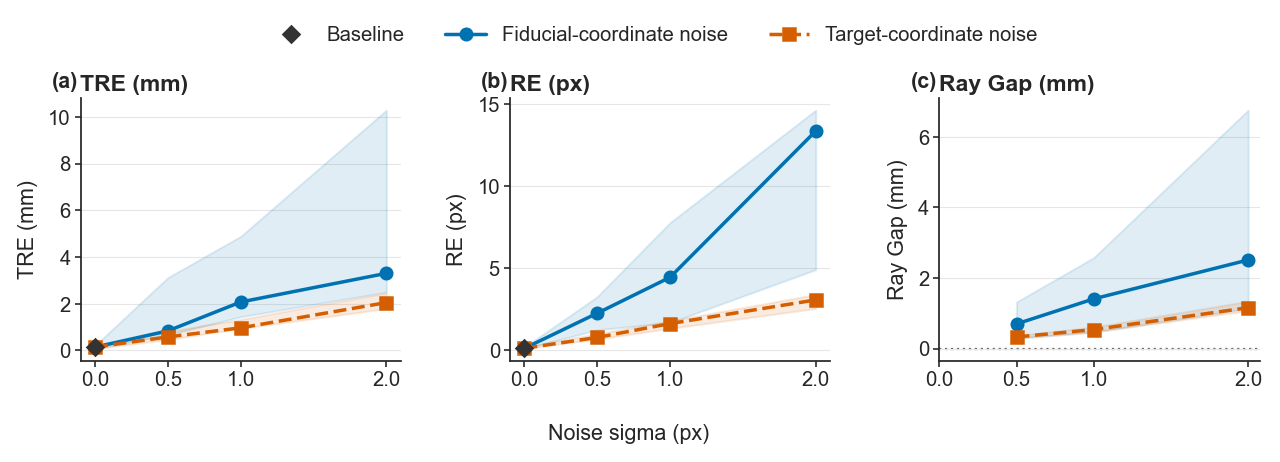

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(TWO_COL, 2.65))
fig.subplots_adjust(left=0.075, right=0.99, bottom=0.25, top=0.80, wspace=0.34)

overall_lookup = {
    "tre": overall_tre_plot,
    "re": overall_re_plot,
    "gap": overall_gap_plot,
}
panel_letters = ["a", "b", "c"]

for ax, key, tag in zip(axes, ["tre", "re", "gap"], panel_letters):
    info = METRIC_INFO[key]
    summary = overall_lookup[key].copy().sort_values(["noise_type", "noise_sigma_px"])

    if key == "gap":
        ax.axhline(0, color="#666666", linewidth=0.9, linestyle=":", zorder=0)
        for noise in NOISE_LINE_ORDER:
            sub = summary[summary["noise_type"].eq(noise)].sort_values("noise_sigma_px")
            ax.fill_between(sub["noise_sigma_px"], sub["q1"], sub["q3"], color=NOISE_COLORS[noise], alpha=0.12)
            ax.plot(
                sub["noise_sigma_px"], sub["center"],
                color=NOISE_COLORS[noise], marker=NOISE_MARKERS[noise],
                linestyle=NOISE_LINESTYLES[noise], label=NOISE_LABELS[noise],
            )
    else:
        baseline_sub = summary[summary["noise_sigma_px"].eq(0.0)].iloc[0]
        ax.errorbar(
            [0.0], [baseline_sub["center"]],
            yerr=[[baseline_sub["center"] - baseline_sub["q1"]], [baseline_sub["q3"] - baseline_sub["center"]]],
            fmt=NOISE_MARKERS["baseline"], color=NOISE_COLORS["baseline"], capsize=2.2,
            linewidth=1.0, label=NOISE_LABELS["baseline"],
        )
        for noise in NOISE_LINE_ORDER:
            sub = summary[summary["noise_type"].eq(noise)].sort_values("noise_sigma_px")
            ax.fill_between(sub["noise_sigma_px"], sub["q1"], sub["q3"], color=NOISE_COLORS[noise], alpha=0.12)
            ax.plot(
                sub["noise_sigma_px"], sub["center"],
                color=NOISE_COLORS[noise], marker=NOISE_MARKERS[noise],
                linestyle=NOISE_LINESTYLES[noise], label=NOISE_LABELS[noise],
            )

    panel_tag(ax, tag)
    ax.set_title(info["label"], loc="left", pad=3, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(info["label"])
    ax.set_xticks(SIGMA_ORDER)
    polish_axis(ax)
    if ax.get_legend() is not None:
        ax.get_legend().remove()

legend_handles = [
    Line2D([0], [0], color=NOISE_COLORS["baseline"], marker=NOISE_MARKERS["baseline"], linestyle="None", label="Baseline"),
    Line2D([0], [0], color=NOISE_COLORS["marker-only"], marker=NOISE_MARKERS["marker-only"], linestyle=NOISE_LINESTYLES["marker-only"], label=NOISE_LABELS["marker-only"]),
    Line2D([0], [0], color=NOISE_COLORS["target-only"], marker=NOISE_MARKERS["target-only"], linestyle=NOISE_LINESTYLES["target-only"], label=NOISE_LABELS["target-only"]),
]
fig.supxlabel("Noise sigma (px)", y=0.075, fontsize=8.6)
fig.legend(handles=legend_handles, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.52, 0.99))
save_fig(fig, "cp_fig01_overall_sigma_response")
plt.show()


In [24]:
sigma_tests_display = sigma_tests.copy()
sigma_tests_display["friedman_stat"] = sigma_tests_display["friedman_stat"].round(4)
sigma_tests_display["friedman_p"] = sigma_tests_display["friedman_p"].map(format_p)
sigma_tests_display["spearman_rho"] = sigma_tests_display["spearman_rho"].round(4)
sigma_tests_display["spearman_p"] = sigma_tests_display["spearman_p"].map(format_p)
sigma_tests_display["baseline_median"] = sigma_tests_display["baseline_median"].round(4)
sigma_tests_display["sigma2_median"] = sigma_tests_display["sigma2_median"].round(4)
sigma_tests_display["sigma2_minus_baseline"] = sigma_tests_display["sigma2_minus_baseline"].round(4)
display(sigma_tests_display)

tre_marker_delta = sigma_tests.query("metric == 'TRE' and noise_type == 'marker-only'")["sigma2_minus_baseline"].iloc[0]
tre_target_delta = sigma_tests.query("metric == 'TRE' and noise_type == 'target-only'")["sigma2_minus_baseline"].iloc[0]
re_marker_delta = sigma_tests.query("metric == 'RE' and noise_type == 'marker-only'")["sigma2_minus_baseline"].iloc[0]
re_target_delta = sigma_tests.query("metric == 'RE' and noise_type == 'target-only'")["sigma2_minus_baseline"].iloc[0]
gap_marker_sigma2 = sigma_tests.query("metric == 'Ray gap' and noise_type == 'marker-only'")["sigma2_median"].iloc[0]
gap_target_sigma2 = sigma_tests.query("metric == 'Ray gap' and noise_type == 'target-only'")["sigma2_median"].iloc[0]

global_md = f'''
### Global findings
- The sigma-response is statistically significant for **all formal tests** in this notebook-level summary.
- At the base-condition median level, `TRE` increases by **{tre_marker_delta:.3f} mm** from baseline to `2 px` under `marker-only`, versus **{tre_target_delta:.3f} mm** under `target-only`.
- `RE` shows an even stronger separation: the baseline-to-`2 px` increase is **{re_marker_delta:.3f} px** for `marker-only` and **{re_target_delta:.3f} px** for `target-only`.
- For `ray gap`, the median value at `2 px` reaches **{gap_marker_sigma2:.3f} mm** under `marker-only` and **{gap_target_sigma2:.3f} mm** under `target-only`.

**Interpretation / 解释**
- Noise amplification is monotonic for all three endpoints.
- `marker-only` perturbations dominate `RE` and `ray gap`, and also produce the larger global `TRE` inflation.
- Because several `marker-only + 2 px` conditions are heavy-tailed, the notebook uses **base-condition medians** as the primary inferential unit.
'''
display(Markdown(global_md))


,metric,noise_type,n_base_conditions,friedman_stat,friedman_p,spearman_rho,spearman_p,baseline_median,sigma2_median,sigma2_minus_baseline
0,TRE,marker-only,9,27.0,<0.001,0.7486,<0.001,0.145,3.3024,3.1574
1,TRE,target-only,9,27.0,<0.001,0.8419,<0.001,0.145,2.0500,1.9050
2,RE,marker-only,9,27.0,<0.001,0.8323,<0.001,0.110,13.3734,13.2634
3,RE,target-only,9,27.0,<0.001,0.9614,<0.001,0.110,3.0621,2.9521
4,Ray gap,marker-only,9,18.0,<0.001,0.5416,0.004,NaN,2.5105,NaN
5,Ray gap,target-only,9,18.0,<0.001,0.9202,<0.001,NaN,1.1582,NaN



### Global findings
- The sigma-response is statistically significant for **all formal tests** in this notebook-level summary.
- At the base-condition median level, `TRE` increases by **3.157 mm** from baseline to `2 px` under `marker-only`, versus **1.905 mm** under `target-only`.
- `RE` shows an even stronger separation: the baseline-to-`2 px` increase is **13.263 px** for `marker-only` and **2.952 px** for `target-only`.
- For `ray gap`, the median value at `2 px` reaches **2.511 mm** under `marker-only` and **1.158 mm** under `target-only`.

**Interpretation / 解释**
- Noise amplification is monotonic for all three endpoints.
- `marker-only` perturbations dominate `RE` and `ray gap`, and also produce the larger global `TRE` inflation.
- Because several `marker-only + 2 px` conditions are heavy-tailed, the notebook uses **base-condition medians** as the primary inferential unit.


## 3. Geometry Modulation of Noise Sensitivity / 几何条件对噪声敏感性的调制

The next two figures convert the analysis from absolute error to **baseline-subtracted error inflation** (`ΔTRE`).  
下面两张图把分析对象从绝对误差改为 **相对 baseline 的误差增量**（`ΔTRE`），更适合回答“哪种几何条件对噪声最敏感”。


Saved: Analysis\figures\experiment_results_analysis\cp_fig02_angle_stratified_tre_delta.png
Saved: Analysis\figures\experiment_results_analysis\cp_fig02_angle_stratified_tre_delta.pdf


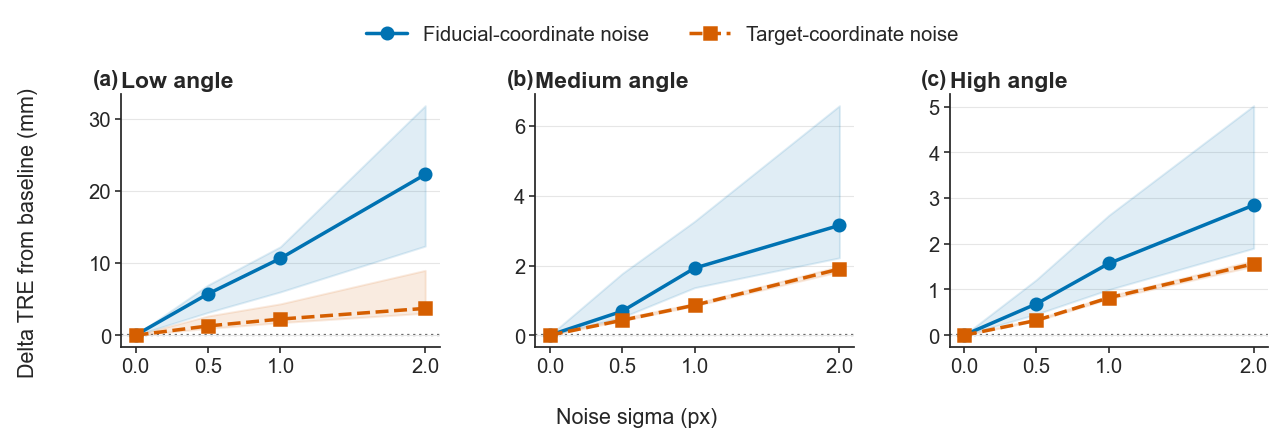

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(TWO_COL, 2.55), sharey=False)
fig.subplots_adjust(left=0.10, right=0.99, bottom=0.25, top=0.80, wspace=0.30)

for ax, angle_group, tag in zip(axes, ANGLE_ORDER, ["a", "b", "c"]):
    summary = (
        angle_tre_plot[angle_tre_plot["angle_group"].eq(angle_group)]
        .sort_values(["noise_type", "noise_sigma_px"])
    )
    ax.axhline(0, color="#666666", linewidth=0.9, linestyle=":", zorder=0)
    for noise in NOISE_LINE_ORDER:
        sub = summary[summary["noise_type"].eq(noise)].sort_values("noise_sigma_px")
        ax.fill_between(sub["noise_sigma_px"], sub["q1"], sub["q3"], color=NOISE_COLORS[noise], alpha=0.12)
        ax.plot(
            sub["noise_sigma_px"], sub["center"],
            color=NOISE_COLORS[noise], marker=NOISE_MARKERS[noise],
            linestyle=NOISE_LINESTYLES[noise], label=NOISE_LABELS[noise],
        )
    panel_tag(ax, tag)
    ax.set_title(f"{angle_group} angle", loc="left", pad=3, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks(SIGMA_ORDER)
    polish_axis(ax)
    if ax.get_legend() is not None:
        ax.get_legend().remove()

fig.supylabel("Delta TRE from baseline (mm)", x=0.020, fontsize=8.6)
fig.supxlabel("Noise sigma (px)", y=0.075, fontsize=8.6)
fig.legend(
    handles=[
        Line2D([0], [0], color=NOISE_COLORS["marker-only"], marker=NOISE_MARKERS["marker-only"], linestyle=NOISE_LINESTYLES["marker-only"], label=NOISE_LABELS["marker-only"]),
        Line2D([0], [0], color=NOISE_COLORS["target-only"], marker=NOISE_MARKERS["target-only"], linestyle=NOISE_LINESTYLES["target-only"], label=NOISE_LABELS["target-only"]),
    ],
    loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.52, 0.99),
)
save_fig(fig, "cp_fig02_angle_stratified_tre_delta")
plt.show()


Saved: Analysis\figures\experiment_results_analysis\cp_fig03_distance_stratified_tre_delta.png
Saved: Analysis\figures\experiment_results_analysis\cp_fig03_distance_stratified_tre_delta.pdf


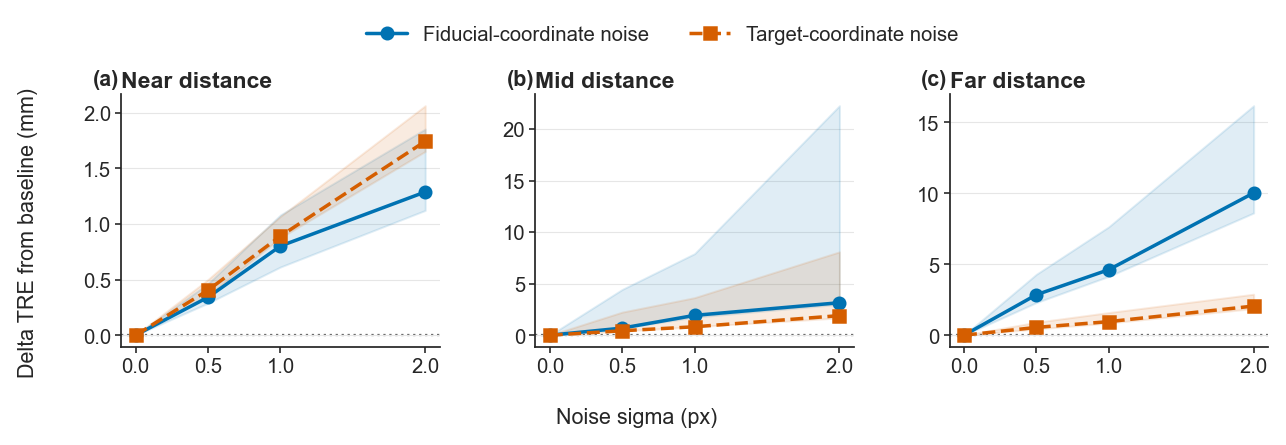

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(TWO_COL, 2.55), sharey=False)
fig.subplots_adjust(left=0.10, right=0.99, bottom=0.25, top=0.80, wspace=0.30)

for ax, distance_group, tag in zip(axes, DISTANCE_ORDER, ["a", "b", "c"]):
    summary = (
        distance_tre_plot[distance_tre_plot["distance_group"].eq(distance_group)]
        .sort_values(["noise_type", "noise_sigma_px"])
    )
    ax.axhline(0, color="#666666", linewidth=0.9, linestyle=":", zorder=0)
    for noise in NOISE_LINE_ORDER:
        sub = summary[summary["noise_type"].eq(noise)].sort_values("noise_sigma_px")
        ax.fill_between(sub["noise_sigma_px"], sub["q1"], sub["q3"], color=NOISE_COLORS[noise], alpha=0.12)
        ax.plot(
            sub["noise_sigma_px"], sub["center"],
            color=NOISE_COLORS[noise], marker=NOISE_MARKERS[noise],
            linestyle=NOISE_LINESTYLES[noise], label=NOISE_LABELS[noise],
        )
    panel_tag(ax, tag)
    ax.set_title(f"{distance_group} distance", loc="left", pad=3, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks(SIGMA_ORDER)
    polish_axis(ax)
    if ax.get_legend() is not None:
        ax.get_legend().remove()

fig.supylabel("Delta TRE from baseline (mm)", x=0.020, fontsize=8.6)
fig.supxlabel("Noise sigma (px)", y=0.075, fontsize=8.6)
fig.legend(
    handles=[
        Line2D([0], [0], color=NOISE_COLORS["marker-only"], marker=NOISE_MARKERS["marker-only"], linestyle=NOISE_LINESTYLES["marker-only"], label=NOISE_LABELS["marker-only"]),
        Line2D([0], [0], color=NOISE_COLORS["target-only"], marker=NOISE_MARKERS["target-only"], linestyle=NOISE_LINESTYLES["target-only"], label=NOISE_LABELS["target-only"]),
    ],
    loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.52, 0.99),
)
save_fig(fig, "cp_fig03_distance_stratified_tre_delta")
plt.show()


In [27]:
angle_summary_display = sigma2_angle_summary.copy()
distance_summary_display = sigma2_distance_summary.copy()
for table in [angle_summary_display, distance_summary_display]:
    for col in ["tre_delta", "re_delta", "gap_delta"]:
        table[col] = table[col].round(4)

display(angle_summary_display)
display(distance_summary_display)

peak_marker_row = sigma2_delta.loc[sigma2_delta["tre_delta"].idxmax()]

geometry_md = f'''
### Geometry modulation
- At `2 px`, the **largest median `ΔTRE`** occurs in the **{peak_marker_row["distance_group"]} / {peak_marker_row["angle_group"]} / marker-only** condition, reaching **{peak_marker_row["tre_delta"]:.3f} mm**.
- The heatmap-style summaries show that `marker-only` sensitivity is especially strong in the **Low-angle** regime.
- By distance, the **Near** point remains comparatively stable, whereas the **Mid** and **Far** points are much more noise-sensitive under `marker-only`.

**Interpretation / 解释**
- The perturbation effect is not explained by noise magnitude alone.
- Geometry modulates how strongly the perturbation is amplified, with low-angle configurations showing the clearest instability.
'''
display(Markdown(geometry_md))


,angle_group,noise_type,tre_delta,re_delta,gap_delta
0,Low,marker-only,22.3070,13.3034,2.5712
1,Low,target-only,3.7214,2.2297,1.0964
2,Medium,marker-only,3.1524,7.6040,1.8418
3,Medium,target-only,1.9000,2.8821,1.1582
4,High,marker-only,2.8463,14.1153,2.5105
5,High,target-only,1.5622,2.8413,1.2310


,distance_group,noise_type,tre_delta,re_delta,gap_delta
0,Near,marker-only,1.2886,3.1415,0.9285
1,Near,target-only,1.7444,2.4571,1.0964
2,Mid,marker-only,3.1524,13.3034,2.5105
3,Mid,target-only,1.9000,3.4074,1.0700
4,Far,marker-only,10.0191,15.5213,6.8594
5,Far,target-only,2.0519,2.8413,1.4367



### Geometry modulation
- At `2 px`, the **largest median `ΔTRE`** occurs in the **Mid / Low / marker-only** condition, reaching **41.378 mm**.
- The heatmap-style summaries show that `marker-only` sensitivity is especially strong in the **Low-angle** regime.
- By distance, the **Near** point remains comparatively stable, whereas the **Mid** and **Far** points are much more noise-sensitive under `marker-only`.

**Interpretation / 解释**
- The perturbation effect is not explained by noise magnitude alone.
- Geometry modulates how strongly the perturbation is amplified, with low-angle configurations showing the clearest instability.


## 4. Fiducial-coordinate Versus Target-coordinate Noise / 两类噪声的直接比较

This section performs paired comparisons within the same base condition and the same sigma level.  
本节在相同 base condition、相同 sigma 水平内，直接比较 `marker-only` 与 `target-only`。


Saved: Analysis\figures\experiment_results_analysis\cp_fig04_marker_vs_target_sigma2.png
Saved: Analysis\figures\experiment_results_analysis\cp_fig04_marker_vs_target_sigma2.pdf


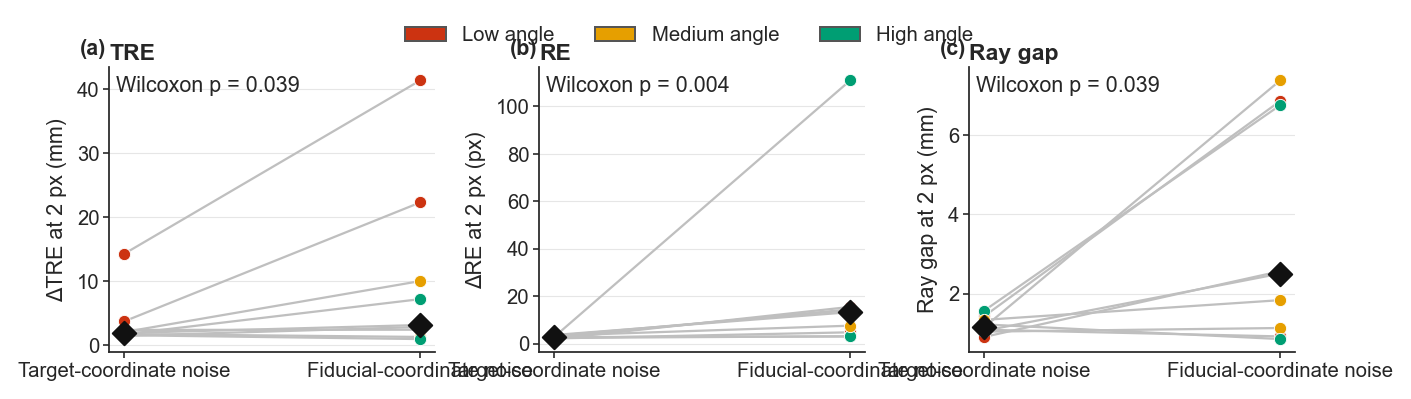

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(TWO_COL, 2.55), sharex=False)
fig.subplots_adjust(left=0.07, right=0.99, bottom=0.24, top=0.86, wspace=0.32)

sigma_focus = 2.0
sigma_focus_df = delta_cell[delta_cell["noise_sigma_px"].eq(sigma_focus)].copy()
panel_specs = [
    ("tre_delta", "ΔTRE at 2 px (mm)", "TRE"),
    ("re_delta", "ΔRE at 2 px (px)", "RE"),
    ("gap_median", "Ray gap at 2 px (mm)", "Ray gap"),
]

for ax, (value_col, ylabel, metric_name), tag in zip(axes, panel_specs, ["a", "b", "c"]):
    pair_df = (
        sigma_focus_df.pivot_table(index="base_condition_id", columns="noise_type", values=value_col, aggfunc="first")
        .reset_index()
        .merge(
            sigma_focus_df[["base_condition_id", "angle_group"]].drop_duplicates(),
            on="base_condition_id",
            how="left",
        )
        .dropna()
    )
    for _, row in pair_df.iterrows():
        ax.plot([0, 1], [row["target-only"], row["marker-only"]], color="#BFBFBF", linewidth=0.9, zorder=1)
        ax.scatter(0, row["target-only"], s=24, color=ANGLE_COLORS[row["angle_group"]], edgecolor="white", linewidth=0.35, zorder=2)
        ax.scatter(1, row["marker-only"], s=24, color=ANGLE_COLORS[row["angle_group"]], edgecolor="white", linewidth=0.35, zorder=2)

    ax.scatter([0, 1], [pair_df["target-only"].median(), pair_df["marker-only"].median()], s=44, color="#111111", marker="D", zorder=3)
    p_text = paired_tests.query("metric == @metric_name and noise_sigma_px == @sigma_focus")["wilcoxon_p"].iloc[0]
    panel_tag(ax, tag)
    ax.set_title(metric_name, loc="left", pad=3, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.set_xticks([0, 1], [NOISE_LABELS["target-only"], NOISE_LABELS["marker-only"]])
    ax.text(0.02, 0.97, f"Wilcoxon p = {format_p(p_text)}", transform=ax.transAxes, ha="left", va="top")
    polish_axis(ax)

fig.legend(
    handles=[Patch(facecolor=ANGLE_COLORS[g], edgecolor="#555555", label=f"{g} angle") for g in ANGLE_ORDER],
    loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.52, 0.99),
)
save_fig(fig, "cp_fig04_marker_vs_target_sigma2")
plt.show()


In [29]:
paired_display = paired_tests.copy()
paired_display["wilcoxon_stat"] = paired_display["wilcoxon_stat"].round(4)
paired_display["wilcoxon_p"] = paired_display["wilcoxon_p"].map(format_p)
paired_display["marker_median"] = paired_display["marker_median"].round(4)
paired_display["target_median"] = paired_display["target_median"].round(4)
paired_display["median_difference_marker_minus_target"] = paired_display["median_difference_marker_minus_target"].round(4)
display(paired_display)

paired_md = f'''
### Paired comparison summary
- For `TRE`, the marker-only penalty becomes statistically significant at **1 px** and remains significant at **2 px**.
- For `RE`, marker-only is significantly worse than target-only at **all three sigma levels**.
- For `ray gap`, marker-only also remains significantly larger than target-only across all tested perturbation levels.

**Interpretation / 解释**
- Direct target perturbation damages localization, but marker perturbation propagates more strongly through the calibration + reconstruction chain.
- This is especially visible in `RE` and `ray gap`, which separate more cleanly than `TRE`.
'''
display(Markdown(paired_md))


,metric,noise_sigma_px,n_base_conditions,wilcoxon_stat,wilcoxon_p,marker_median,target_median,median_difference_marker_minus_target
0,TRE,0.5,9,6.0,0.055,0.6891,0.4292,0.3028
1,TRE,1.0,9,4.0,0.027,1.9251,0.8913,1.1060
2,TRE,2.0,9,5.0,0.039,3.1524,1.9000,1.3895
3,RE,0.5,9,0.0,0.004,2.1607,0.5946,1.3613
4,RE,1.0,9,2.0,0.012,4.3537,1.4566,2.6770
5,RE,2.0,9,0.0,0.004,13.3034,2.8413,9.6285
6,Ray gap,0.5,9,3.0,0.020,0.6987,0.3294,0.3693
7,Ray gap,1.0,9,3.0,0.020,1.4082,0.5389,0.7839
8,Ray gap,2.0,9,5.0,0.039,2.5105,1.1582,1.4405



### Paired comparison summary
- For `TRE`, the marker-only penalty becomes statistically significant at **1 px** and remains significant at **2 px**.
- For `RE`, marker-only is significantly worse than target-only at **all three sigma levels**.
- For `ray gap`, marker-only also remains significantly larger than target-only across all tested perturbation levels.

**Interpretation / 解释**
- Direct target perturbation damages localization, but marker perturbation propagates more strongly through the calibration + reconstruction chain.
- This is especially visible in `RE` and `ray gap`, which separate more cleanly than `TRE`.


## 5. Interaction Map and Tail Diagnostics / 交互热图与长尾诊断

The next figure shows the geometry-specific `ΔTRE` at `2 px`, followed by a diagnostic table that explains why robust statistics are preferred.


Saved: Analysis\figures\experiment_results_analysis\cp_fig05_tre_heatmap_sigma2.png
Saved: Analysis\figures\experiment_results_analysis\cp_fig05_tre_heatmap_sigma2.pdf


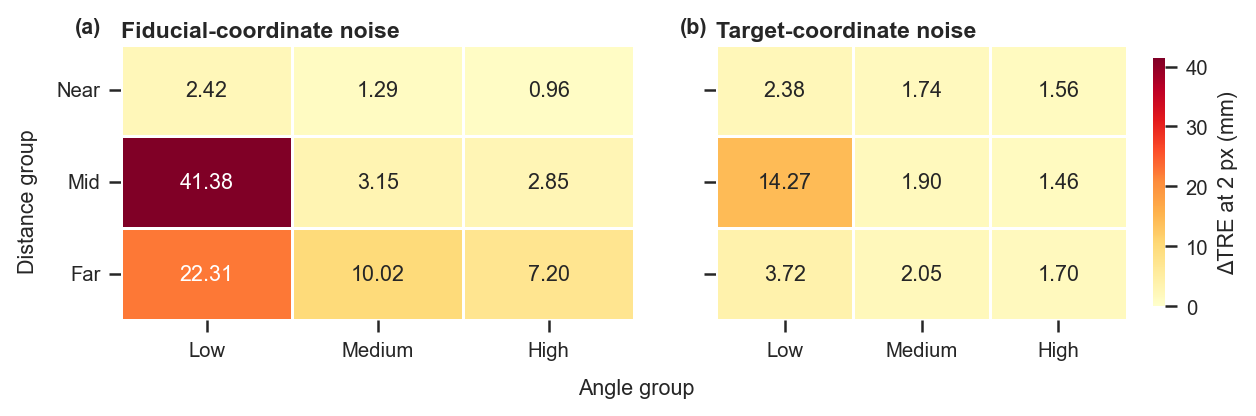

In [30]:
vmax = max(float(np.nanmax(heatmap_tre_marker.values)), float(np.nanmax(heatmap_tre_target.values)))

fig, axes = plt.subplots(1, 2, figsize=(TWO_COL, 2.55), sharey=True)
fig.subplots_adjust(left=0.10, right=0.96, bottom=0.24, top=0.84, wspace=0.16)

for ax, data, title, tag in zip(
    axes,
    [heatmap_tre_marker, heatmap_tre_target],
    [NOISE_LABELS["marker-only"], NOISE_LABELS["target-only"]],
    ["a", "b"],
):
    sns.heatmap(
        data,
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap="YlOrRd",
        linewidths=0.5,
        linecolor="white",
        vmin=0,
        vmax=vmax,
        cbar=ax is axes[-1],
        cbar_kws={"shrink": 0.90, "label": "ΔTRE at 2 px (mm)"} if ax is axes[-1] else None,
    )
    panel_tag(ax, tag)
    ax.set_title(title, loc="left", pad=3, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(ANGLE_ORDER, rotation=0)
    ax.set_yticklabels(DISTANCE_ORDER, rotation=0)

fig.supxlabel("Angle group", y=0.070, fontsize=8.6)
fig.supylabel("Distance group", x=0.020, fontsize=8.6)
save_fig(fig, "cp_fig05_tre_heatmap_sigma2")
plt.show()


In [31]:
display(heavy_tail_table.head(12))
display(max_rows)

tail_md = f'''
### Tail diagnostics
- The strongest heavy-tail behavior appears in **marker-only** conditions, particularly at **2 px**.
- The largest observed single-run `TRE` is **{max_rows["tre_mm_raw"].iloc[0]:.3f} mm**.
- Several conditions show a `mean / median` ratio above **1.5**, confirming that mean-only summaries would be overly sensitive to rare extreme perturbation draws.

**Practical consequence / 实际意义**
- The notebook therefore uses **base-condition medians** for the main inferential plots and tables.
- Means are still reported as supplementary context, but they are not the primary manuscript statistic.
'''
display(Markdown(tail_md))


,distance_group,angle_group,noise_type,noise_sigma_px,tre_mean,tre_median,re_mean,re_median,tre_mean_median_ratio,re_mean_median_ratio
0,Mid,Low,marker-only,2.0,64.610867,41.588301,18.831539,13.373401,1.553583,1.408134
1,Mid,High,marker-only,2.0,4.113429,2.966349,36.691130,14.205258,1.386698,2.582926
2,Far,High,marker-only,2.0,10.101821,7.342403,91.944319,111.299493,1.375819,0.826098
3,Near,Medium,marker-only,2.0,1.822569,1.338593,4.555608,3.221503,1.361556,1.414125
4,Mid,Low,marker-only,1.0,19.051205,14.114621,7.352599,6.414585,1.349750,1.146231
5,Far,Medium,target-only,1.0,1.609881,1.225717,2.082960,1.786234,1.313420,1.166118
6,Mid,Low,marker-only,0.5,11.014643,8.397689,3.673946,3.259897,1.311628,1.127013
7,Mid,Low,target-only,0.5,5.505768,4.259450,1.564754,1.317021,1.292601,1.188101
8,Far,Low,marker-only,2.0,29.309784,22.777003,24.044890,15.841254,1.286815,1.517865
9,Near,Low,target-only,2.0,3.108300,2.464301,2.424511,2.329728,1.261331,1.040684


,experiment_record_id,point_id,distance_group,angle_group,noise_type,noise_sigma_px,repeat_index,tre_mm_raw,re_px_raw,ray_gap_mm_raw
2560,20260421_210815_814229,tp_-85.52_58.91_-96.65,Mid,Low,marker-only,2.0,7,627.273729,56.912975,1.772427
2577,20260421_210823_564016,tp_-85.52_58.91_-96.65,Mid,Low,marker-only,2.0,24,202.973092,27.101428,0.397201
2581,20260421_210825_636303,tp_-85.52_58.91_-96.65,Mid,Low,marker-only,2.0,28,191.306060,43.568356,1.887109
2579,20260421_210824_564971,tp_-85.52_58.91_-96.65,Mid,Low,marker-only,2.0,26,165.334220,46.475999,5.202791
2594,20260421_210832_683115,tp_-85.52_58.91_-96.65,Mid,Low,marker-only,2.0,41,159.402615,40.112790,0.318637
2595,20260421_210833_216933,tp_-85.52_58.91_-96.65,Mid,Low,marker-only,2.0,42,138.139493,45.540357,1.861163
2559,20260421_210815_435750,tp_-85.52_58.91_-96.65,Mid,Low,marker-only,2.0,6,129.673636,49.841323,4.017211
2566,20260421_210818_084335,tp_-85.52_58.91_-96.65,Mid,Low,marker-only,2.0,13,125.898534,35.386850,3.167499
1074,20260421_203918_704511,tp_-141.15_-53.01_-92.41,Far,Low,marker-only,2.0,21,112.723409,49.702890,22.961577
1064,20260421_203914_960986,tp_-141.15_-53.01_-92.41,Far,Low,marker-only,2.0,11,82.543375,38.146500,19.128264



### Tail diagnostics
- The strongest heavy-tail behavior appears in **marker-only** conditions, particularly at **2 px**.
- The largest observed single-run `TRE` is **627.274 mm**.
- Several conditions show a `mean / median` ratio above **1.5**, confirming that mean-only summaries would be overly sensitive to rare extreme perturbation draws.

**Practical consequence / 实际意义**
- The notebook therefore uses **base-condition medians** for the main inferential plots and tables.
- Means are still reported as supplementary context, but they are not the primary manuscript statistic.


## 6. Exported Tables and Paper-Ready Text / 导出表格与论文文字草稿

This final section exports compact CSV tables and generates manuscript-ready narrative text.


In [32]:
# Export compact analysis tables
qc_summary.to_csv(TABLE_DIR / "cp_table_qc_summary.csv", index=False)
matrix_table.to_csv(TABLE_DIR / "cp_table_design_matrix.csv", index=False)
baseline_count_table.to_csv(TABLE_DIR / "cp_table_baseline_counts.csv", index=False)
sigma_tests.to_csv(TABLE_DIR / "cp_table_sigma_tests.csv", index=False)
paired_tests.to_csv(TABLE_DIR / "cp_table_marker_vs_target_tests.csv", index=False)
sigma2_angle_summary.to_csv(TABLE_DIR / "cp_table_sigma2_angle_summary.csv", index=False)
sigma2_distance_summary.to_csv(TABLE_DIR / "cp_table_sigma2_distance_summary.csv", index=False)
heavy_tail_table.to_csv(TABLE_DIR / "cp_table_tail_diagnostics.csv", index=False)

export_md = "### Exported tables\n" + "\n".join(
    f"- `{p.name}`" for p in sorted(TABLE_DIR.glob("cp_table_*.csv"))
)
display(Markdown(export_md))


### Exported tables
- `cp_table_baseline_counts.csv`
- `cp_table_design_matrix.csv`
- `cp_table_marker_vs_target_tests.csv`
- `cp_table_qc_summary.csv`
- `cp_table_sigma2_angle_summary.csv`
- `cp_table_sigma2_distance_summary.csv`
- `cp_table_sigma_tests.csv`
- `cp_table_tail_diagnostics.csv`

In [33]:
tre_marker_p = paired_tests.query("metric == 'TRE' and noise_sigma_px == 2.0")["wilcoxon_p"].iloc[0]
re_marker_p = paired_tests.query("metric == 'RE' and noise_sigma_px == 2.0")["wilcoxon_p"].iloc[0]
gap_marker_p = paired_tests.query("metric == 'Ray gap' and noise_sigma_px == 2.0")["wilcoxon_p"].iloc[0]

low_marker_delta = sigma2_angle_summary.query("angle_group == 'Low' and noise_type == 'marker-only'")["tre_delta"].iloc[0]
high_marker_delta = sigma2_angle_summary.query("angle_group == 'High' and noise_type == 'marker-only'")["tre_delta"].iloc[0]
far_marker_gap = sigma2_distance_summary.query("distance_group == 'Far' and noise_type == 'marker-only'")["gap_delta"].iloc[0]
near_marker_gap = sigma2_distance_summary.query("distance_group == 'Near' and noise_type == 'marker-only'")["gap_delta"].iloc[0]

results_text = f'''
### Results paragraph draft

A total of **{len(df)}** valid rows were analyzed, including **{int(df["noise_type"].eq("baseline").sum())}** clean-baseline rows and **{int(df["analysis_row_kind"].eq("perturbation_run").sum())}** perturbation rows. The controlled perturbation matrix was complete, covering **9 base conditions** (`3 distances x 3 angle groups`) with balanced perturbation sampling (`2 noise types x 3 non-zero sigma levels x 50 repeats`). To avoid instability from heavy-tailed perturbation draws, the primary inferential unit was the **base-condition median**.

Increasing perturbation strength produced a monotonic deterioration in all endpoints. Friedman tests on the base-condition medians confirmed significant sigma effects for `TRE` and `RE` under both `marker-only` and `target-only` perturbations (all `p {sigma_tests.query("metric == 'TRE'")["friedman_p"].map(format_p).iloc[0]}`). For `ray gap`, significant within-perturbation sigma effects were also observed for both noise types (all `p < 0.001`). At `2 px`, the median `TRE` inflation was larger for `marker-only` than for `target-only`, and this difference was significant in paired testing (`p = {format_p(tre_marker_p)}`). The separation was even clearer for `RE` (`p = {format_p(re_marker_p)}`) and `ray gap` (`p = {format_p(gap_marker_p)}`).

Noise sensitivity was strongly modulated by geometry. Under `marker-only`, the median `ΔTRE` at `2 px` reached **{low_marker_delta:.2f} mm** in the **Low-angle** group, compared with **{high_marker_delta:.2f} mm** in the **High-angle** group. Distance-dependent amplification was also evident for `ray gap`, with the `Far` condition reaching **{far_marker_gap:.2f} mm** versus **{near_marker_gap:.2f} mm** for the `Near` condition. These results indicate that perturbation effects are governed jointly by noise magnitude and reconstruction geometry, rather than by noise level alone.

### 中文写作提示
- 主结果建议以 `TRE` 为核心终点，`RE` 和 `ray gap` 作为机制支持指标。
- 论文图的主线可以写成：**noise sigma ↑ -> error ↑；marker-only > target-only；low-angle / non-near geometry 最敏感**。
'''
display(Markdown(results_text))



### Results paragraph draft

A total of **2754** valid rows were analyzed, including **54** clean-baseline rows and **2700** perturbation rows. The controlled perturbation matrix was complete, covering **9 base conditions** (`3 distances x 3 angle groups`) with balanced perturbation sampling (`2 noise types x 3 non-zero sigma levels x 50 repeats`). To avoid instability from heavy-tailed perturbation draws, the primary inferential unit was the **base-condition median**.

Increasing perturbation strength produced a monotonic deterioration in all endpoints. Friedman tests on the base-condition medians confirmed significant sigma effects for `TRE` and `RE` under both `marker-only` and `target-only` perturbations (all `p <0.001`). For `ray gap`, significant within-perturbation sigma effects were also observed for both noise types (all `p < 0.001`). At `2 px`, the median `TRE` inflation was larger for `marker-only` than for `target-only`, and this difference was significant in paired testing (`p = 0.039`). The separation was even clearer for `RE` (`p = 0.004`) and `ray gap` (`p = 0.039`).

Noise sensitivity was strongly modulated by geometry. Under `marker-only`, the median `ΔTRE` at `2 px` reached **22.31 mm** in the **Low-angle** group, compared with **2.85 mm** in the **High-angle** group. Distance-dependent amplification was also evident for `ray gap`, with the `Far` condition reaching **6.86 mm** versus **0.93 mm** for the `Near` condition. These results indicate that perturbation effects are governed jointly by noise magnitude and reconstruction geometry, rather than by noise level alone.

### 中文写作提示
- 主结果建议以 `TRE` 为核心终点，`RE` 和 `ray gap` 作为机制支持指标。
- 论文图的主线可以写成：**noise sigma ↑ -> error ↑；marker-only > target-only；low-angle / non-near geometry 最敏感**。


In [34]:
discussion_text = f'''
### Discussion paragraph draft

The controlled perturbation analysis suggests that the dominant failure mode in the present workflow is not merely 2D localization noise itself, but the way in which that noise is amplified by the underlying imaging geometry. Direct target perturbation (`target-only`) degraded reconstruction accuracy in a predictable manner, yet calibration perturbation (`marker-only`) produced a substantially larger penalty, especially in `RE` and `ray gap`. This pattern indicates that calibration uncertainty propagates through the full geometric reconstruction chain and can dominate downstream reconstruction error when the acquisition geometry is unfavorable.

The strongest instability occurred in the low-angle configurations, where even moderate perturbation levels produced large `ΔTRE` increases. This finding is consistent with the intuition that narrower angular separation weakens the triangulation constraint and leaves the reconstruction more vulnerable to calibration and localization errors. Distance further modulated this sensitivity: the non-near points, particularly the far point, showed markedly larger perturbation-driven `ray gap` values than the near point. Accordingly, future work should treat perturbation robustness as a **geometry-dependent property**, rather than as a single global algorithm characteristic.

A practical implication is that manuscript-level summaries should rely on robust cell-level statistics rather than raw pooled means. In the current dataset, several `marker-only + 2 px` conditions exhibited heavy-tailed behavior, with rare but very large failures that strongly inflated the mean. The median-centered analysis used here therefore provides a more stable estimate of the typical perturbation response while still preserving the tail behavior in the supplementary diagnostics. For TMI-style reporting, this combination of robust primary statistics and explicit tail diagnostics is likely to be more defensible than a mean-only presentation.
'''
display(Markdown(discussion_text))



### Discussion paragraph draft

The controlled perturbation analysis suggests that the dominant failure mode in the present workflow is not merely 2D localization noise itself, but the way in which that noise is amplified by the underlying imaging geometry. Direct target perturbation (`target-only`) degraded reconstruction accuracy in a predictable manner, yet calibration perturbation (`marker-only`) produced a substantially larger penalty, especially in `RE` and `ray gap`. This pattern indicates that calibration uncertainty propagates through the full geometric reconstruction chain and can dominate downstream reconstruction error when the acquisition geometry is unfavorable.

The strongest instability occurred in the low-angle configurations, where even moderate perturbation levels produced large `ΔTRE` increases. This finding is consistent with the intuition that narrower angular separation weakens the triangulation constraint and leaves the reconstruction more vulnerable to calibration and localization errors. Distance further modulated this sensitivity: the non-near points, particularly the far point, showed markedly larger perturbation-driven `ray gap` values than the near point. Accordingly, future work should treat perturbation robustness as a **geometry-dependent property**, rather than as a single global algorithm characteristic.

A practical implication is that manuscript-level summaries should rely on robust cell-level statistics rather than raw pooled means. In the current dataset, several `marker-only + 2 px` conditions exhibited heavy-tailed behavior, with rare but very large failures that strongly inflated the mean. The median-centered analysis used here therefore provides a more stable estimate of the typical perturbation response while still preserving the tail behavior in the supplementary diagnostics. For TMI-style reporting, this combination of robust primary statistics and explicit tail diagnostics is likely to be more defensible than a mean-only presentation.
